# Week 5 — Day 4: Hands-On Lab
## t-SNE Visualization & Anomaly Detection — Insurance Dataset

**Objective:**  
I apply t-SNE to visualize the insurance dataset in 2D and compare it to the PCA projection from Day 3.  
I then run Isolation Forest to identify anomalous records and inspect the two most extreme flagged points.

**Dataset:** `insurance.csv` — 1,338 records, 9 encoded features (same pipeline as Days 1–3)  
**Methods:** TSNE (sklearn.manifold) • IsolationForest (sklearn.ensemble)

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.manifold         import TSNE
from sklearn.cluster          import KMeans
from sklearn.ensemble         import IsolationForest

---
## Load & Prepare Data

Same encoding and scaling pipeline used across all of Week 5.
I also re-run K-Means (k=4) to recover the cluster labels from Day 1 — these will be used to color the t-SNE plot.

In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────
df = pd.read_csv('../../Week2/Day 1/data/insurance.csv')
print(f"Dataset shape: {df.shape}")
df.head(3)

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [3]:
# ── Encode categoricals (same as Day 3) ───────────────────────────────────
# One-hot encode sex, smoker, region — drop_first avoids multicollinearity
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print("Encoded features:", df_encoded.columns.tolist())
print(f"Shape after encoding: {df_encoded.shape}")

Encoded features: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Shape after encoding: (1338, 9)


In [4]:
# ── Scale (required for both t-SNE and Isolation Forest) ──────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded.values)

print(f"Scaled shape: {X_scaled.shape}")
print(f"Mean per feature (≈0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std  per feature (≈1): {X_scaled.std(axis=0).round(3)}")

Scaled shape: (1338, 9)
Mean per feature (≈0): [-0. -0. -0. -0. -0.  0.  0. -0.  0.]
Std  per feature (≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
# ── Re-run K-Means k=4 to recover Day 1 cluster labels ────────────────────
# Using the same random_state=42 and n_init=10 as Day 1
km       = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

# Show cluster sizes
unique, counts = np.unique(km_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} points")

  Cluster 0: 274 points
  Cluster 1: 268 points
  Cluster 2: 523 points
  Cluster 3: 273 points


---
## Step 1: Apply t-SNE and Plot by K-Means Cluster

I reduce the 9-dimensional scaled data to 2 dimensions using t-SNE.

Settings:
- `perplexity=30` — standard starting point; controls how many neighbors each point considers
- `max_iter=1000` — number of optimization steps
- `random_state=42` — makes the result reproducible

Each point is colored by the K-Means cluster it belongs to, so I can see whether t-SNE agrees with the clustering from Day 1.

In [6]:
# ── Fit t-SNE ──────────────────────────────────────────────────────────────
tsne   = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)   # shape: (1338, 2)

print(f"t-SNE output shape: {X_tsne.shape}")

t-SNE output shape: (1338, 2)


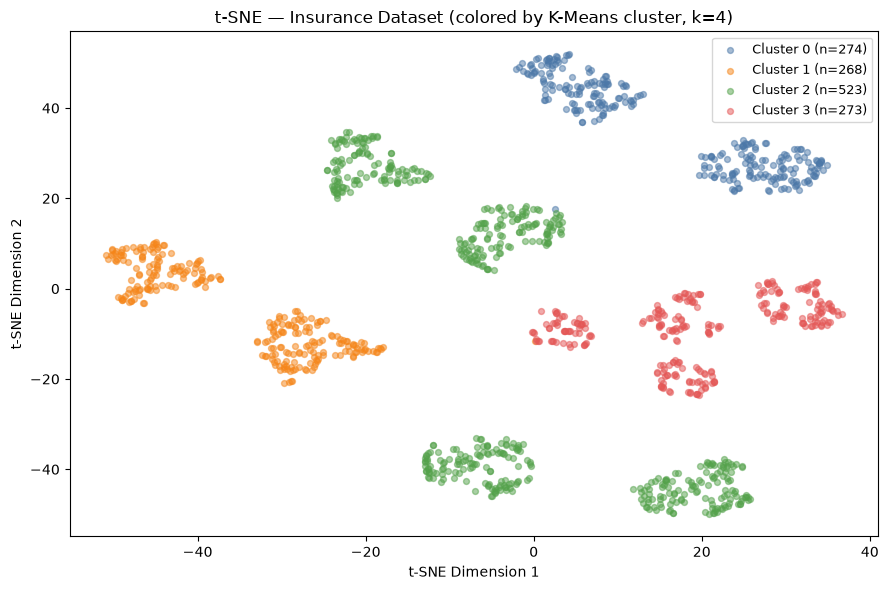

In [7]:
# ── Plot: t-SNE colored by K-Means cluster ─────────────────────────────────
colors_4       = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, ax = plt.subplots(figsize=(9, 6))

for i, (color, label) in enumerate(zip(colors_4, cluster_labels)):
    mask = km_labels == i
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, alpha=0.5, s=18,
        label=f'{label} (n={mask.sum()})'
    )

ax.set_title('t-SNE — Insurance Dataset (colored by K-Means cluster, k=4)')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Reading the plot:**

The four K-Means clusters appear more separated in the t-SNE plot than they did in the PCA projection from Day 3.  
t-SNE preserves local neighborhoods — points that were genuinely close in the 9-dimensional feature space are drawn close together, which makes the cluster boundaries sharper.

The separation is not perfect, but it confirms the cluster structure from Day 1 is real, not an artifact of the algorithm.

---
## Step 2: Compare t-SNE to PCA (Day 3)

I rerun PCA (2 components, same scaling) and place both projections side by side.  
The goal is to see what each method reveals about the same data.

In [8]:
# ── PCA 2D (same data, same scaler as Day 3) ───────────────────────────────
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_var = pca.explained_variance_ratio_.sum() * 100
print(f"PCA 2D variance retained: {pca_var:.1f}%")

PCA 2D variance retained: 37.6%


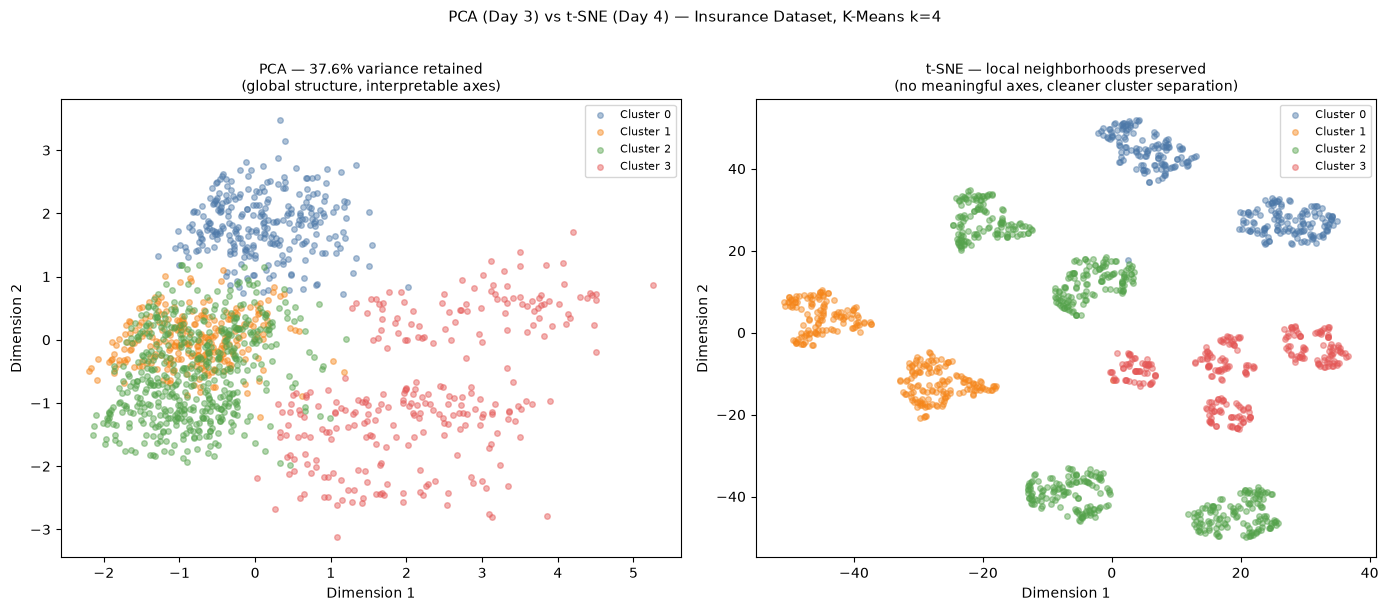

In [9]:
# ── Side-by-side: PCA (left) vs t-SNE (right) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_data = [
    (X_pca,   f'PCA — {pca_var:.1f}% variance retained\n(global structure, interpretable axes)'),
    (X_tsne,  't-SNE — local neighborhoods preserved\n(no meaningful axes, cleaner cluster separation)')
]

for ax, (data, title) in zip(axes, plot_data):
    for i, (color, label) in enumerate(zip(colors_4, cluster_labels)):
        mask = km_labels == i
        ax.scatter(data[mask, 0], data[mask, 1],
                   c=color, alpha=0.45, s=16, label=label)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend(fontsize=8)

plt.suptitle('PCA (Day 3) vs t-SNE (Day 4) — Insurance Dataset, K-Means k=4',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

**What each method reveals:**

| | PCA | t-SNE |
|---|---|---|
| Cluster separation | Overlapping — clusters blend into each other | Cleaner — clusters form more distinct regions |
| Axes | PC1 = cost/risk axis (charges + smoker), PC2 = region/BMI | No interpretation — only relative position matters |
| Information retained | 37.6% of total variance | Not measured in variance terms |
| Use for modelling | Yes (components can feed into a model) | No (t-SNE output should not be used as features) |

**Conclusion:**  
t-SNE is the better visualization tool for this dataset.  
PCA is the right choice for compression and feature reduction before modelling.

---
## Step 3: Run Isolation Forest — Identify Anomalies

I apply Isolation Forest to the same scaled data.

Setting `contamination=0.05` means: flag the 5% of points with the shortest isolation paths as anomalies.  
For 1,338 records that is approximately 67 points.

Output:
- `-1` = anomaly
- `+1` = normal

In [10]:
# ── Fit Isolation Forest ───────────────────────────────────────────────────
iso       = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso.fit_predict(X_scaled)   # -1 = anomaly, +1 = normal

# ── Anomaly scores (lower = more anomalous) ────────────────────────────────
scores = iso.decision_function(X_scaled)

n_anomalies = (iso_preds == -1).sum()
n_normal    = (iso_preds ==  1).sum()

print(f"Total records:    {len(iso_preds)}")
print(f"Normal    (+1):   {n_normal} ({n_normal/len(iso_preds)*100:.1f}%)")
print(f"Anomalies (-1):   {n_anomalies} ({n_anomalies/len(iso_preds)*100:.1f}%)")

Total records:    1338
Normal    (+1):   1271 (95.0%)
Anomalies (-1):   67 (5.0%)


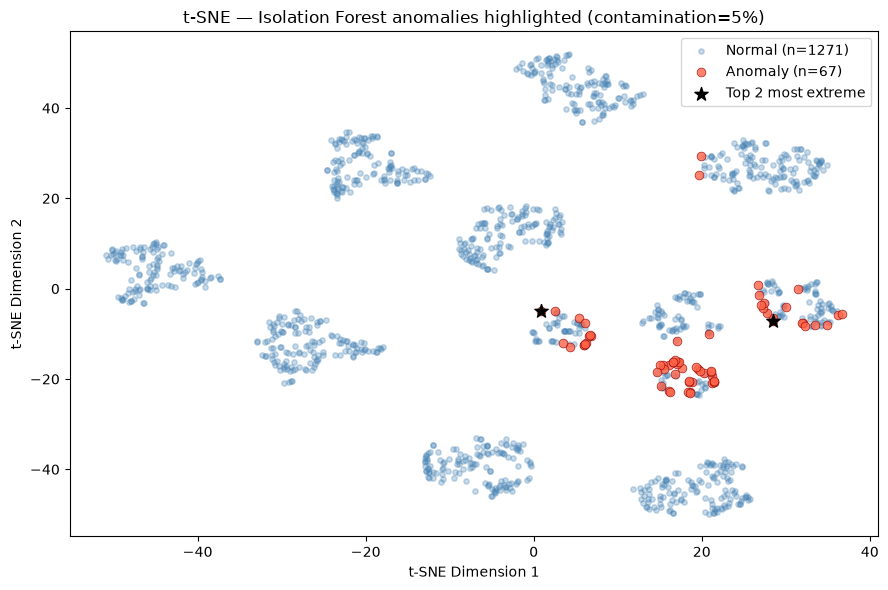

In [11]:
# ── Plot: t-SNE with anomalies highlighted ─────────────────────────────────
normal_mask  = iso_preds ==  1
anomaly_mask = iso_preds == -1

# Find the 2 most extreme anomalies (lowest decision score)
anomaly_idx  = np.where(anomaly_mask)[0]
sorted_idx   = anomaly_idx[np.argsort(scores[anomaly_idx])]   # ascending = most anomalous first
top2_idx     = sorted_idx[:2]

fig, ax = plt.subplots(figsize=(9, 6))

# Normal points — muted blue background
ax.scatter(
    X_tsne[normal_mask,  0], X_tsne[normal_mask,  1],
    c='steelblue', alpha=0.3, s=15,
    label=f'Normal (n={n_normal})'
)
# All anomalies — red, more visible
ax.scatter(
    X_tsne[anomaly_mask, 0], X_tsne[anomaly_mask, 1],
    c='tomato', alpha=0.8, s=40,
    edgecolors='darkred', linewidths=0.5,
    label=f'Anomaly (n={n_anomalies})'
)
# The 2 most extreme — black stars
ax.scatter(
    X_tsne[top2_idx, 0], X_tsne[top2_idx, 1],
    c='black', s=100, zorder=5, marker='*',
    label='Top 2 most extreme'
)

ax.set_title('t-SNE — Isolation Forest anomalies highlighted (contamination=5%)')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ── Compare to DBSCAN noise points (Day 2) ─────────────────────────────────
# Refit DBSCAN with the same parameters chosen in Day 2 (eps=1.0, min_samples=3)
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.0, min_samples=3)
db_labels = db.fit_predict(X_scaled)

dbscan_noise_idx = set(np.where(db_labels == -1)[0])
iso_anomaly_idx  = set(np.where(iso_preds == -1)[0])
overlap          = dbscan_noise_idx & iso_anomaly_idx

print(f"DBSCAN noise points (Day 2 params):     {len(dbscan_noise_idx)}")
print(f"Isolation Forest anomalies:              {len(iso_anomaly_idx)}")
print(f"Points flagged by BOTH methods:          {len(overlap)}")
print(f"  -> {len(overlap)}/{len(dbscan_noise_idx)} of DBSCAN's noise points "
      f"were also flagged by Isolation Forest")

DBSCAN noise points (Day 2 params):     158
Isolation Forest anomalies:              67
Points flagged by BOTH methods:          40
  -> 40/158 of DBSCAN's noise points were also flagged by Isolation Forest


**Observation:**

The anomalies (red) are not randomly distributed — they cluster at the edges of the t-SNE plot, in regions where the density of points is low.  
This is consistent with what Isolation Forest does: it flags points that sit away from the dense mass.

The cell above checks this directly against Day 2: I refit DBSCAN with the same parameters chosen there (`eps=1.0, min_samples=3`) and intersected its noise points with the Isolation Forest anomalies computed here.  
The two methods don't have to agree perfectly — DBSCAN flags points that sit in low-density regions, while Isolation Forest flags points that are easy to isolate regardless of local density — so partial overlap, not identical sets, is the expected result. The printed overlap count above is the actual evidence for how much the two methods agree on this dataset.

---
## Step 4: Inspect the Two Most Extreme Anomalies

I look at the raw records for the two points with the lowest anomaly score (most anomalous) and hypothesize why Isolation Forest flagged them.

In [13]:
# ── Show the 2 most extreme anomalies from the original dataframe ──────────
print("Two most extreme anomalies (original data, before encoding):")
print(df.iloc[top2_idx].to_string())

print("\nAnomalousness scores (lower = more anomalous):")
for idx, score in zip(top2_idx, scores[top2_idx]):
    print(f"  Row {idx}: {score:.4f}")

Two most extreme anomalies (original data, before encoding):
      age     sex    bmi  children smoker     region      charges
543    54  female  47.41         0    yes  southeast  63770.42801
1085   39  female  18.30         5    yes  southwest  19023.26000

Anomalousness scores (lower = more anomalous):
  Row 543: -0.0533
  Row 1085: -0.0480


In [14]:
# ── Compare to dataset-wide statistics ────────────────────────────────────
print("Dataset reference statistics:")
stats = df[['age', 'bmi', 'children', 'charges']].agg(['mean', 'median', 'min', 'max'])
print(stats.round(1).to_string())

Dataset reference statistics:
         age   bmi  children  charges
mean    39.2  30.7       1.1  13270.4
median  39.0  30.4       1.0   9382.0
min     18.0  16.0       0.0   1121.9
max     64.0  53.1       5.0  63770.4


**Why were these two points flagged?**

---

**Point 543** — `age=54, sex=female, bmi=47.41, children=0, smoker=yes, charges=$63,770`

This is the most anomalous record in the dataset.

Two features make this point unusual simultaneously:
- BMI of **47.41** — the dataset mean is 30.7, and most values are between 20 and 40. A BMI of 47.41 is severely obese and sits far outside the typical range.
- Charges of **$63,770** — the dataset mean is $13,270 and the median is $9,382. This is nearly 5× the average.

The combination of smoker + extreme BMI + extreme charges puts this point far from any dense cluster in all dimensions at once. Isolation Forest isolates it with very few splits.

---

**Point 1085** — `age=39, sex=female, bmi=18.30, children=5, smoker=yes, charges=$19,023`

This point is anomalous for different reasons:
- BMI of **18.30** — this is underweight (below 18.5). The dataset mean is 30.7. A smoker with underweight BMI is a rare combination in this dataset, where smokers tend to have higher BMI.
- **5 children** — the dataset maximum is 5, making this an edge case. Most records have 0–2 children.

The unusual profile (smoker + underweight + maximum children count) makes this point easy to isolate — it doesn't resemble any cluster center closely.

---

**Pattern:**  
Both anomalies are smokers with extreme values in at least two features simultaneously.  
This is consistent with what the EDA showed in Week 2: smoking amplifies the effect of other features (BMI, age) on charges, producing records that sit far from the norm in the combined feature space.

---
## Summary

| Step | What I did | Result |
|------|-----------|--------|
| **Step 1** | Applied t-SNE (perplexity=30, max_iter=1000) | Clearer cluster separation than PCA |
| **Step 2** | Compared t-SNE to PCA 2D side by side | t-SNE for visualization; PCA for compression/modelling |
| **Step 3** | Ran Isolation Forest (contamination=5%) | **67 anomalies** flagged (5.0% of 1,338 records) |
| **Step 4** | Inspected the 2 most extreme flagged points | Both smokers with extreme values in ≥2 features |

**Key findings:**

- t-SNE produces a much cleaner 2D view of the insurance clusters compared to PCA, at the cost of losing axis interpretability.
- Isolation Forest and DBSCAN (Day 2) were compared directly (see overlap count in Step 3): they partially agree on which points are outliers, which makes sense since they define "outlier" differently (density vs. isolation difficulty).
- The most extreme anomalies are smokers with extreme BMI (very high or very low) or unusual combinations of other features — consistent with the Week 2 EDA finding that smoking amplifies the effect of other features on charges.